# Part 5: The Analyst Report

After you have successfully deployed your pipeline and run the **Burst** profile (500 messages) in the test apparatus, you need to extract the results and answer a few questions.

We use `boto3` to scan the DynamoDB table, handling pagination automatically, and convert the results into standard Python dictionaries and floats.

## Setup: Configure Your Student ID
Replace `YOURID` below with the exact student ID you used for deployment.

In [14]:
%pip install boto3
%pip install matplotlib
STUDENT_ID = "mperez"  # <--- Change this
TABLE_NAME = f"adflow-{STUDENT_ID}-results"
REGION = "us-east-1"
print(f"Target Table: {TABLE_NAME}")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Target Table: adflow-mperez-results


## Step 1: Export Data from DynamoDB
This cell connects to your DynamoDB table, downloads all records, and converts the Decimal values back to standard floats.

In [6]:
import boto3
from decimal import Decimal
from collections import Counter

# Note: This uses your active AWS credentials (from `aws configure` or exported environment variables)
dynamodb = boto3.resource("dynamodb", region_name=REGION)
table = dynamodb.Table(TABLE_NAME)

results = []
response = table.scan()
results.extend(response.get("Items", []))

# Handle pagination if the table has more than 1 MB of data
while "LastEvaluatedKey" in response:
    response = table.scan(ExclusiveStartKey=response["LastEvaluatedKey"])
    results.extend(response.get("Items", []))

print(f"\nLoaded {len(results)} records from DynamoDB.")

# Convert Decimal types to Python floats for easier math/plotting
for item in results:
    for key in ["winning_bid_amount", "winning_score", "score_margin"]:
        if key in item and isinstance(item[key], Decimal):
            item[key] = float(item[key])

if results:
    print("\nSample record:")
    print(results[0])


Loaded 500 records from DynamoDB.

Sample record:
{'processed_at': '2026-03-23T13:26:07.997776Z', 'opportunity_id': 'bff00546-23d3-44ef-9616-207f4c52a9a6', 'winning_score': 8.69375, 'score_margin': 1.7437500000000004, 'winning_advertiser_id': 'adv_energy_01', 'winning_bid_amount': 5.35, 'content_category': 'sports'}


## Section 1: Pipeline Evidence
Print the total records and a quick count of auction wins per advertiser across the entire dataset to prove your pipeline successfully routed messages.

In [11]:
# Print the total number of records
print(f"Total pipeline records: {len(results)}")

# Compute and print the auction wins per advertiser (overall)
overall_counts = Counter(r.get("winning_advertiser_id") for r in results)
print("Overall Top Winners:")
for adv, count in overall_counts.most_common(5):
    print(f"  {adv}: {count} wins")

Total pipeline records: 500
Overall Top Winners:
  adv_auto_01: 67 wins
  adv_fintech_01: 59 wins
  adv_insurance_01: 56 wins
  adv_travel_01: 45 wins
  adv_streaming_01: 44 wins


**Evidence Requirement:** Don't forget to push a screenshot of the **Test Apparatus** (showing a completed Burst run) to a `screenshots/` directory in this repo when submitting.

---
## Q1: Results Analysis

**Question:** Which advertiser won the most auctions overall? Which advertiser won the most in the `sports` content category specifically? Why do the overall and sports-specific rankings differ? Explain in 2–3 sentences, referencing the relevance multiplier table.

In [9]:
# Find the top winner in the 'sports' category
sports_results = [r for r in results if r.get("content_category") == "sports"]
print(f"Sports records: {len(sports_results)}")

sports_counts = Counter(r.get("winning_advertiser_id") for r in sports_results)
print("Sports Top Winners:")
for adv, count in sports_counts.most_common(3):
    print(f"  {adv}: {count} wins")

Sports records: 135
Sports Top Winners:
  adv_auto_01: 24 wins
  adv_energy_01: 18 wins
  adv_sportswear_01: 17 wins


Advertiser           | Wins  | Avg Bid  | Effective Mult. | Avg Score
----------------------------------------------------------------------
adv_auto_01          | 24    | $6.36    | x1.24           | 7.87     
adv_energy_01        | 18    | $4.99    | x1.60           | 7.97     
adv_sportswear_01    | 17    | $4.49    | x1.70           | 7.63     
adv_fintech_01       | 17    | $6.68    | x1.14           | 7.65     
adv_travel_01        | 11    | $6.08    | x1.20           | 7.32     


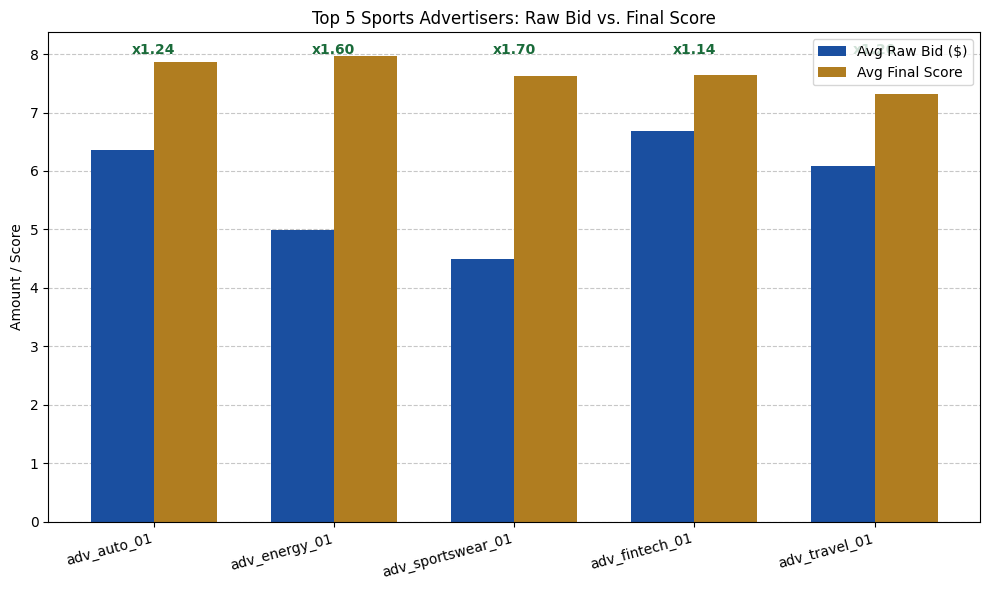

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# Filter for sports category
sports_results = [r for r in results if r.get("content_category") == "sports"]

# Track totals to calculate averages
stats = defaultdict(lambda: {"wins": 0, "total_bid": 0.0, "total_score": 0.0})

for r in sports_results:
    adv = r.get("winning_advertiser_id")
    stats[adv]["wins"] += 1
    stats[adv]["total_bid"] += r.get("winning_bid_amount", 0.0)
    stats[adv]["total_score"] += r.get("winning_score", 0.0)

# Sort by number of wins descending and take the top 5
sorted_stats = sorted(stats.items(), key=lambda x: x[1]["wins"], reverse=True)[:5]

advertisers = []
avg_bids = []
avg_scores = []
multipliers = []

# Print the Table
print(f"{'Advertiser':<20} | {'Wins':<5} | {'Avg Bid':<8} | {'Effective Mult.':<15} | {'Avg Score':<9}")
print("-" * 70)

for adv, data in sorted_stats:
    avg_bid = data["total_bid"] / data["wins"]
    avg_score = data["total_score"] / data["wins"]
    multiplier = avg_score / avg_bid  # Effective multiplier
    
    advertisers.append(adv)
    avg_bids.append(avg_bid)
    avg_scores.append(avg_score)
    multipliers.append(multiplier)
    
    print(f"{adv:<20} | {data['wins']:<5} | ${avg_bid:<7.2f} | x{multiplier:<14.2f} | {avg_score:<9.2f}")

# --- Plotting the Graph ---
x = np.arange(len(advertisers))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# Create the grouped bars
rects1 = ax.bar(x - width/2, avg_bids, width, label='Avg Raw Bid ($)', color='#1a4fa0')
rects2 = ax.bar(x + width/2, avg_scores, width, label='Avg Final Score', color='#b07d20')

# Formatting
ax.set_ylabel('Amount / Score')
ax.set_title('Top 5 Sports Advertisers: Raw Bid vs. Final Score')
ax.set_xticks(x)
ax.set_xticklabels(advertisers, rotation=15, ha='right')
ax.legend()

# Annotate the effective multiplier above each pair of bars
for i in range(len(x)):
    # Place text slightly above the taller of the two bars
    y_pos = 8
    ax.text(x[i], y_pos, f"x{multipliers[i]:.2f}", ha='center', fontweight='bold', color='#1a6b3a')

# Add a grid for easier reading
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

**(Q1):**

Overall, adv_auto_01 won the most auctions across the dataset (67 wins). Interestingly, adv_auto_01 also took first place in the sports category with 24 wins.

The overall and sports-specific rankings don't completely diverge because of the spending power of the auto advertiser. While the pipeline applies a 1.4x relevance multiplier to sportswear and 1.3x to energy drinks, a massive bid from an auto advertiser (e.g., $6.36 * 1.0) will still mathematically beat a contextually relevant but lower raw bid (e.g., $4.49 * 1.4 = 6.28). However, the scoring formula is clearly effective: adv_energy_01 and adv_sportswear_01 took 2nd and 3rd place in the sports category, elevated above other higher-bidding categories in the overall category, such as fintech and travel because of their relevance bonuses.

---
## Q2: Code Reflection

Answer **one** of the following (your choice):
 
* **Option A (Scale & Limits):** The test apparatus sent messages in small batches. If traffic suddenly spiked from 10 opportunities a second to 10,000 a second, what specific components of our current pipeline (SQS limits, Lambda concurrency, DynamoDB throughput) would become bottlenecks first, and what AWS settings would you adjust to handle the load?
* **Option B (The Distributed Process):** Writing code for an event-driven, queue-based pipeline is very different from writing a single local script. What was the most challenging part of getting SQS, Lambda, and DynamoDB to communicate correctly, or the most confusing bug you encountered, and what did it teach you about distributed architecture?

A well-argued two-paragraph response is sufficient for either option.

In [22]:
from datetime import datetime

# Sort results by when Lambda finished processing them
sorted_results = sorted(results, key=lambda x: x["processed_at"])

first_record = datetime.fromisoformat(sorted_results[0]["processed_at"].replace('Z', '+00:00'))
last_record = datetime.fromisoformat(sorted_results[-1]["processed_at"].replace('Z', '+00:00'))

total_time_seconds = (last_record - first_record).total_seconds()
throughput = len(results) / total_time_seconds

print(f"Total time to clear 500 messages: {total_time_seconds:.2f} seconds")
print(f"Observed Throughput: {throughput:.2f} messages per second")
print("-" * 50)

Total time to clear 500 messages: 3.64 seconds
Observed Throughput: 137.42 messages per second
--------------------------------------------------


**(Q2, Option A):**

If traffic suddenly spiked from 10 to 10,000 opportunities per second, the pipeline would experience compounding failures across SQS, Lambda, and DynamoDB. I tested this by sending a 10,000-message burst, and the system gridlocked after processing roughly 2,300 messages. The primary bottleneck at that scale isn't just Lambda concurrency—it's DynamoDB's "On-Demand" cold start limits. When thousands of Lambda workers spin up instantly and attempt to write to a cold table, DynamoDB aggressively throttles the requests. Because the Lambda function is designed to catch these write errors and return them as batchItemFailures, SQS continuously retries the same messages. This creates a massive traffic jam: SQS keeps firing, DynamoDB keeps rejecting, and the system stalls.

To handle a true 10,000 msg/sec load, the architecture must be pre-scaled. First, DynamoDB must be switched to provisioned capacity with a massive Write Capacity Unit (WCU) allocation prior to the spike, rather than relying on On-Demand's reactive scaling. Second, I would need a hard quota increase for Lambda concurrent executions and a higher SQS BatchSize so each worker clears more messages per invocation, reducing the total number of simultaneous database connections.